<a href="https://colab.research.google.com/github/RobertsEshenvalds/test/blob/main/06_LogisticRegression_Iris_unsolved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression — Iris Classification 🌸

In this notebook you will practise building a logistic regression classifier to predict **iris species** from petal and sepal measurements.

**Skills covered:**
1. Loading & exploring the dataset
2. Preparing features and target
3. Train/test split
4. Fitting a logistic regression model (scikit-learn)
5. Evaluating with accuracy, confusion matrix, and classification report
6. Visualising the decision boundary (2-feature case)
7. Predicting probabilities

**Dataset:** Iris — available via `sklearn.datasets.load_iris()` or `sns.load_dataset("iris")`.  
Each row describes an iris flower with four measurements: sepal length, sepal width, petal length, petal width.

Fill in every cell marked with `# YOUR CODE HERE` — the surrounding code and comments tell you what is expected.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
%matplotlib inline


## 1. Load the dataset

Load the Iris dataset into a pandas DataFrame and display the first 5 rows.  
*Hint:* `load_iris(as_frame=True)` returns a Bunch with a `.frame` attribute.


In [12]:
iris = load_iris(as_frame=
True
)
df = iris.frame
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 2. Quick EDA

**2a.** Print the shape and check for missing values.

In [13]:
print("Shape:", df.shape)
print()
print(df.isnull().sum())


Shape: (150, 5)

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


**2b.** How many samples are there per class? Print the value counts of the `target` column.  
The target values 0, 1, 2 correspond to setosa, versicolor, virginica.


In [14]:
print(df["target"].value_counts())
print()
print("Class names:", iris.target_names)

target
0    50
1    50
2    50
Name: count, dtype: int64

Class names: ['setosa' 'versicolor' 'virginica']


**2c.** Create a pair plot of the four features, coloured by `target`.


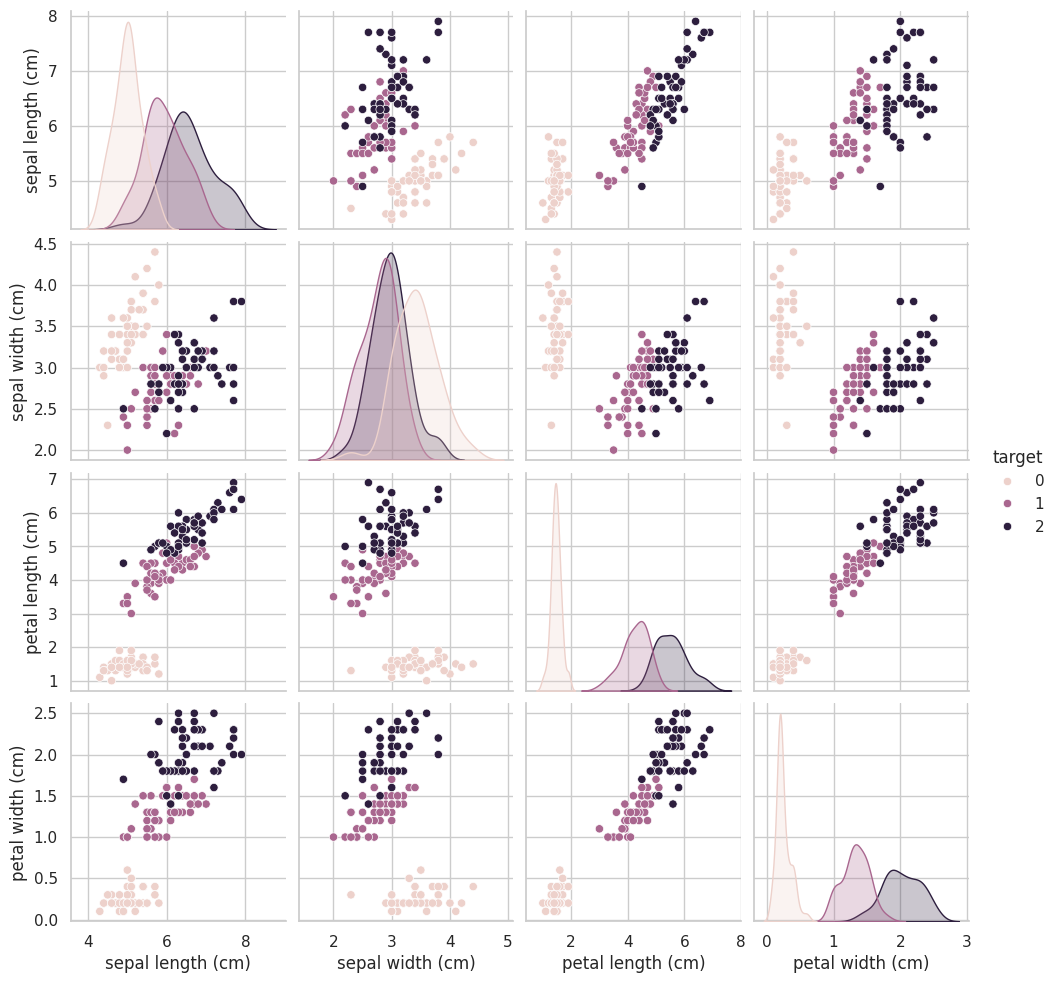

In [15]:
sns.pairplot(df, hue="target")
plt.show()

## 3. Prepare features and target

**3a.** Create the feature matrix `X` (all columns except `target`) and the target vector `y` (the `target` column).


In [16]:
X = df.drop(columns=["target"])
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


## 4. Train / test split

Split the data into training (80 %) and test (20 %) sets.  
Use `random_state=42` and `stratify=y` to keep class proportions balanced.


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape," Test:", X_test.shape)


Train: (120, 4)  Test: (30, 4)


## 5. Feature scaling

Logistic regression benefits from scaled features. Fit a `StandardScaler` on the **training** set and transform both train and test sets.


In [18]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)


## 6. Fit the logistic regression model

Create a `LogisticRegression` object (use `max_iter=200` to ensure convergence) and fit it on the **scaled training** data.


In [19]:
model = LogisticRegression(max_iter=200)
model.fit(X_train_sc, y_train)

LogisticRegression(max_iter=200)

## 7. Make predictions

Use the fitted model to predict class labels on the **scaled test** set.


In [20]:
y_pred = model.predict(X_test_sc)
y_pred


array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 1, 2, 2, 1, 0, 2, 0])

## 8. Evaluate the model

**8a.** Compute the accuracy on the test set.


In [21]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")


Accuracy: 0.9333


**8b.** Compute and display the confusion matrix.


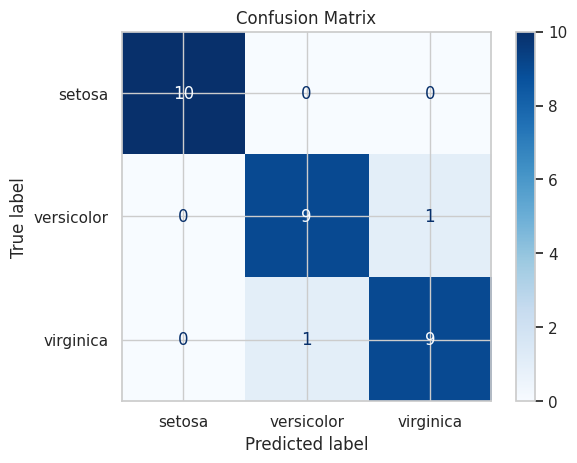

In [22]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=iris.target_names).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


**8c.** Print the full classification report (precision, recall, F1 per class).


In [23]:
print(classification_report(y_test, y_pred, target_names=iris.target_names))


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 9. Predicted probabilities

**9a.** Use `predict_proba` to get class probabilities for the test set. Display the first 5 rows as a DataFrame.


In [24]:
proba = model.predict_proba(X_test_sc)
pd.DataFrame(proba, columns=iris.target_names).head()


,setosa,versicolor,virginica
0,0.978818,0.021182,3.638218e-07
1,0.003798,0.369220,6.269815e-01
2,0.148799,0.842475,8.726064e-03
3,0.095445,0.894619,9.936370e-03
4,0.988493,0.011507,1.725496e-07


**9b.** What does each row of probabilities sum to? Verify by printing the sum of the first row.


In [25]:
print(f"Sum of first row: {proba[0].sum():.4f}")
# Each row sums to 1.0 because the three probabilities represent all of the possible outcomes (1.0 = 100%)


Sum of first row: 1.0000


## 10. Visualise a 2-feature decision boundary

**10.** To visualise the decision boundary we reduce to just two features: `petal length (cm)` and `petal width (cm)`.  
The plotting code is provided — you only need to fit a new model on the 2-feature scaled data.


In [26]:
#Select two features
X2 = df[["petal length (cm)", "petal width (cm)"]]
y2 = df["target"]
X2_train, X2_test, y2_train, y2_test = train_test_split(
X2, y2, test_size=0.2, random_state=42, stratify=y2
)
scaler2 = StandardScaler()
X2_train_sc = scaler2.fit_transform(X2_train)
X2_test_sc = scaler2.transform(X2_test)

# YOUR CODE HERE — fit a LogisticRegression on the 2-feature scaled training data
model2 = LogisticRegression(max_iter=200)
model2.fit(X2_train_sc, y2_train)

# ── Plot decision boundary (provided) ──
h = 0.02
x_min, x_max = X2_train_sc[:, 0].min() - 1, X2_train_sc[:, 0].max() + 1
y_min, y_max = X2_train_sc[:, 1].min() - 1, X2_train_sc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
np.arange(y_min, y_max, h))
Z = model2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

---
**Well done!** You have built, evaluated, and visualised a logistic regression classifier from scratch.
